# 프로젝트: 한국어 데이터로 챗봇 만들기

## 프로젝트 제출 루브릭

| 학습목표 | 평가기준 |
|---|---|
| 한국어 전처리를 통해 학습 데이터셋을 구축하였다. | 공백과 특수문자 처리, 토크나이징, 병렬데이터 구축의 과정이 적절히 진행되었다. |
| 트랜스포머 모델을 구현하여 한국어 챗봇 모델 학습을 정상적으로 진행하였다. | 구현한 트랜스포머 모델이 한국어 병렬 데이터 학습 시 안정적으로 수렴하였다. |
| 한국어 입력문장에 대해 한국어로 답변하는 함수를 구현하였다. | 한국어 입력문장에 맥락에 맞는 한국어로 답변을 리턴하였다. |

In [1]:
# [환경 설정] 필요한 라이브러리와 재현성 시드를 설정합니다.
# BASE_DIR은 데이터, SentencePiece 모델, 학습 체크포인트를 한곳에 저장하는 작업 폴더입니다.
# CUDA가 있으면 GPU를 사용하고, 없으면 CPU로 자동 전환합니다.

# %pip install sentencepiece pandas matplotlib

import os
import re
import gc
import math
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import sentencepiece as spm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Windows/Jupyter와 Linux/Jupyter 모두에서 동작하도록 홈 경로를 사용합니다.
BASE_DIR = Path('~/work/transformer_chatbot/data').expanduser()
BASE_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE = BASE_DIR / 'ChatbotData.csv'
CORPUS_FILE = BASE_DIR / 'clean_corpus.txt'
SP_MODEL_PREFIX = BASE_DIR / 'spm_korean'
SP_MODEL_FILE = Path(str(SP_MODEL_PREFIX) + '.model')

# RTX 3050 Ti 4GB에서는 현재 배치만 GPU에 올리고, CPU DataLoader가 다음 배치를 준비합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 하이퍼파라미터 설정

모델 구조와 학습 조건은 아래 셀에서 한 번에 조정합니다. 데이터 처리·모델 생성·학습 셀에서는 이 변수들을 참조하므로, 실험할 때는 이 셀만 수정하면 됩니다.

| 분류 | 변수 | 설명 |
|---|---|---|
| 데이터 | `MAX_SAMPLES`, `MAX_LENGTH`, `VALID_RATIO` | 사용할 샘플 수, 최대 시퀀스 길이, 검증 비율 |
| 모델 | `D_MODEL`, `NUM_HEADS`, `FF_DIM`, `NUM_LAYERS`, `DROPOUT` | Transformer 구조와 정규화 설정 |
| 토크나이저 | `VOCAB_SIZE_LIMIT` | SentencePiece vocabulary 최대 크기 |
| 학습 | `BATCH_SIZE`, `LEARNING_RATE`, `WEIGHT_DECAY`, `EPOCHS` | 배치와 최적화 조건 |
| 메모리 | `ACCUMULATION_STEPS` | gradient accumulation 횟수 |


## 성능 개선 포인트

기존 로그는 12 epoch 부근부터 검증 손실이 정체된 뒤 상승하고, 학습 손실만 계속 감소하므로 과적합이 확인됩니다. 따라서 PAD를 제외한 토큰 단위 집계, label smoothing, 검증 손실 기반 학습률 감소, best checkpoint 저장, early stopping을 적용했습니다. 또한 입력 길이를 48로 늘리고 FFN 용량을 보강했으며, 추론 시 반복 2-gram을 억제합니다.


In [2]:
# [개선된 하이퍼파라미터]
# 검증 손실이 가장 낮은 지점의 가중치를 저장하고, 이후 과적합을 조기 종료합니다.
MAX_SAMPLES = 12000
MAX_LENGTH = 48
VALID_RATIO = 0.1
VOCAB_SIZE_LIMIT = 4000

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.15

LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-5
LABEL_SMOOTHING = 0.05
EPOCHS = 30
PATIENCE = 5
MIN_DELTA = 1e-3

ACCUMULATION_STEPS = 4 if device.type == 'cuda' else 1
BATCH_SIZE = 4 if device.type == 'cuda' else 32

print('개선된 하이퍼파라미터 설정 완료')
print({
    'MAX_SAMPLES': MAX_SAMPLES, 'MAX_LENGTH': MAX_LENGTH,
    'D_MODEL': D_MODEL, 'NUM_HEADS': NUM_HEADS,
    'FF_DIM': FF_DIM, 'NUM_LAYERS': NUM_LAYERS,
    'BATCH_SIZE': BATCH_SIZE, 'EPOCHS': EPOCHS,
    'LABEL_SMOOTHING': LABEL_SMOOTHING, 'PATIENCE': PATIENCE
})

개선된 하이퍼파라미터 설정 완료
{'MAX_SAMPLES': 12000, 'MAX_LENGTH': 48, 'D_MODEL': 128, 'NUM_HEADS': 4, 'FF_DIM': 512, 'NUM_LAYERS': 2, 'BATCH_SIZE': 4, 'EPOCHS': 30, 'LABEL_SMOOTHING': 0.05, 'PATIENCE': 5}


## Step 1. 데이터 수집하기

송영숙님이 공개한 `ChatbotData.csv`를 사용합니다. 이미 `~/work/cornell_movie_dialogs/ChatbotData.csv`가 있으면 로컬 파일을 사용하고, 없으면 GitHub 원본에서 다운로드합니다.

데이터에는 일반적으로 `Q`(질문), `A`(답변), `label` 열이 포함됩니다. `label`은 학습 입력으로 사용하지 않고 질문과 답변만 사용합니다.

In [3]:
# [데이터 수집] 로컬에 데이터가 있으면 재사용하고, 없으면 GitHub에서 다운로드합니다.
# pandas로 CSV를 읽어 질문(Q)과 답변(A) 열의 구조를 먼저 확인합니다.

DATA_URLS = [
    'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData%20.csv',
    'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv',
]

if not DATA_FILE.exists():
    last_error = None
    for data_url in DATA_URLS:
        try:
            urllib.request.urlretrieve(data_url, DATA_FILE)
            print('다운로드 완료:', DATA_FILE)
            break
        except Exception as exc:
            last_error = exc
    else:
        raise RuntimeError(f'데이터 다운로드에 실패했습니다: {last_error}')
else:
    print('기존 로컬 데이터 사용:', DATA_FILE)

raw_df = pd.read_csv(DATA_FILE)
print('원본 shape:', raw_df.shape)
print(raw_df.head())
print('열 이름:', list(raw_df.columns))

기존 로컬 데이터 사용: C:\Users\eaglesjo\work\transformer_chatbot\data\ChatbotData.csv
원본 shape: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
열 이름: ['Q', 'A', 'label']


## Step 2. 데이터 전처리하기

한국어는 영어처럼 소문자 변환을 강제하지 않습니다. 대신 공백을 정규화하고, 제어문자·과도한 반복 공백을 정리합니다. 질문과 답변이 비어 있거나 지나치게 긴 샘플은 제외하고 중복 쌍도 제거합니다.

`MAX_LENGTH`는 토큰화 이후의 최대 길이입니다. 4GB VRAM 환경에서는 40 정도로 시작하고, 메모리가 부족하면 32로 낮춥니다.

In [4]:
# [데이터 전처리] 대화 문장의 줄바꿈과 반복 공백을 정리합니다.
# 빈 문장·결측값·중복 질문-답변 쌍을 제거하여 학습에 사용할 pairs를 만듭니다.

def clean_text(text):
    text = str(text).replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

required_cols = {'Q', 'A'}
missing = required_cols - set(raw_df.columns)
if missing:
    raise ValueError(f'필수 열이 없습니다: {missing}')

pairs = []
for _, row in raw_df[['Q', 'A']].dropna().iterrows():
    q, a = clean_text(row['Q']), clean_text(row['A'])
    if q and a:
        pairs.append((q, a))

pairs = list(dict.fromkeys(pairs))[:MAX_SAMPLES]
print('전처리 후 질문-답변 쌍:', len(pairs))
print('샘플:', pairs[:3])

전처리 후 질문-답변 쌍: 11750
샘플: [('12시 땡!', '하루가 또 가네요.'), ('1지망 학교 떨어졌어', '위로해 드립니다.'), ('3박4일 놀러가고 싶다', '여행은 언제나 좋죠.')]


## Step 3. SentencePiece 사용하기

SentencePiece BPE 모델을 대화 corpus에 맞춰 학습합니다. 모델 파일은 현재 작업 폴더가 아니라 `BASE_DIR`에 저장하여 Windows/Jupyter의 상대 경로 권한 문제를 피합니다.

Teacher Forcing을 위해 한 답변 시퀀스를 다음처럼 시프트합니다.

> 원본: `[BOS, I, AM, A, STUDENT, EOS, PAD, ...]`
>
> 디코더 입력: `[BOS, I, AM, A, STUDENT, EOS, PAD, ...]`에서 마지막 토큰 제거
>
> 레이블: `[I, AM, A, STUDENT, EOS, PAD, ...]`에서 첫 토큰 제거


In [5]:
# [토크나이저 학습] 질문과 답변으로 SentencePiece BPE를 학습합니다.
# vocab을 고정 4000으로 두되, 실제 생성된 크기를 모델에 사용합니다.
with CORPUS_FILE.open('w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + '\n')
        f.write(a + '\n')

for suffix in ('.model', '.vocab'):
    old_file = Path(str(SP_MODEL_PREFIX) + suffix)
    if old_file.exists():
        old_file.unlink()

spm.SentencePieceTrainer.Train(
    input=str(CORPUS_FILE), model_prefix=str(SP_MODEL_PREFIX),
    vocab_size=min(VOCAB_SIZE_LIMIT, 4000), character_coverage=1.0,
    model_type='bpe', max_sentence_length=999999,
    bos_id=1, eos_id=2, pad_id=0, unk_id=3, hard_vocab_limit=False
)
sp = spm.SentencePieceProcessor()
sp.Load(str(SP_MODEL_FILE))
PAD_ID, BOS_ID, EOS_ID, UNK_ID = sp.pad_id(), sp.bos_id(), sp.eos_id(), sp.unk_id()
VOCAB_SIZE = sp.GetPieceSize()
print('SentencePiece vocab size:', VOCAB_SIZE)

sample = '안녕하세요. 오늘 기분은 어떠세요?'
print('토큰:', sp.encode(sample, out_type=str))
print('복원:', sp.decode(sp.encode(sample, out_type=int)))

SentencePiece vocab size: 4000
토큰: ['▁안녕', '하세요', '.', '▁오늘', '▁기분', '은', '▁어', '떠', '세요', '?']
복원: 안녕하세요. 오늘 기분은 어떠세요?


In [6]:
# [Dataset과 Teacher Forcing] 문장을 고정 길이 정수 시퀀스로 바꾸고 PAD로 채웁니다.
# 답변 시퀀스를 한 칸 이동하여 decoder 입력(a_ids[:-1])과 정답(a_ids[1:])을 만듭니다.
# 마지막으로 학습/검증 데이터와 DataLoader를 구성합니다.

class ChatbotDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length=40):
        self.samples = []
        for q_text, a_text in pairs:
            q_ids = [BOS_ID] + tokenizer.encode(q_text, out_type=int) + [EOS_ID]
            a_ids = [BOS_ID] + tokenizer.encode(a_text, out_type=int) + [EOS_ID]
            if len(q_ids) > max_length or len(a_ids) > max_length:
                continue
            q_ids += [PAD_ID] * (max_length - len(q_ids))
            a_ids += [PAD_ID] * (max_length - len(a_ids))
            self.samples.append((
                torch.tensor(q_ids, dtype=torch.long),
                torch.tensor(a_ids[:-1], dtype=torch.long),
                torch.tensor(a_ids[1:], dtype=torch.long),
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]

full_dataset = ChatbotDataset(pairs, sp, MAX_LENGTH)
if len(full_dataset) < 10:
    raise RuntimeError('길이 필터 후 샘플이 너무 적습니다. MAX_LENGTH를 늘려 보세요.')

valid_size = max(1, int(len(full_dataset) * 0.1))
train_size = len(full_dataset) - valid_size
train_dataset, valid_dataset = random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(device.type == 'cuda')
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(device.type == 'cuda')
)

enc, dec_in, labels = full_dataset[0]
print('Dataset size:', len(full_dataset))
print('encoder:', enc.shape, 'decoder input:', dec_in.shape, 'labels:', labels.shape)

Dataset size: 11750
encoder: torch.Size([48]) decoder input: torch.Size([47]) labels: torch.Size([47])


## Step 4. 모델 구성하기

다음 구현은 Transformer의 핵심 요소를 직접 포함합니다.

- Scaled dot-product attention
- Multi-head attention
- Positional encoding
- Encoder self-attention
- Decoder masked self-attention과 encoder–decoder cross-attention
- Padding mask와 look-ahead mask

디코더의 self-attention에서는 미래 정답을 보지 못하도록 상삼각 look-ahead 마스크를 적용합니다.

In [7]:
# [Transformer 핵심 구현] Attention, positional encoding, encoder, decoder를 직접 구현합니다.
# mask의 True 위치는 attention에서 제외되며, decoder는 미래 토큰을 볼 수 없습니다.
# Encoder-Decoder 구조는 입력 문장을 memory로 요약하고 답변을 자기회귀적으로 생성합니다.

def padding_mask(tokens):
    # [B, L] -> [B, 1, 1, L], True인 위치는 attention에서 제외
    return (tokens == PAD_ID).unsqueeze(1).unsqueeze(2)

def look_ahead_mask(tokens):
    batch, length = tokens.shape
    future = torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=tokens.device),
        diagonal=1
    )
    pad = padding_mask(tokens).squeeze(1)  # [B, 1, L]
    return future.unsqueeze(0).unsqueeze(1) | pad.unsqueeze(2)

def scaled_dot_product_attention(q, k, v, mask=None):
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(mask, torch.finfo(scores.dtype).min)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, v), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError('d_model은 num_heads로 나누어져야 합니다.')
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        b, l, _ = x.shape
        return x.view(b, l, self.num_heads, self.depth).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        q = self.split_heads(self.q_proj(q))
        k = self.split_heads(self.k_proj(k))
        v = self.split_heads(self.v_proj(v))
        x, weights = scaled_dot_product_attention(q, k, v, mask)
        x = x.transpose(1, 2).contiguous().view(x.size(0), -1, self.num_heads * self.depth)
        return self.dropout(self.out_proj(x)), weights

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=MAX_LENGTH):
        super().__init__()
        position = torch.arange(max_length).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_length, d_model)
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, d_model))
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        a, _ = self.attn(x, x, x, mask)
        x = self.norm1(x + self.drop(a))
        return self.norm2(x + self.drop(self.ff(x)))

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, d_model))
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, self_mask, memory_mask):
        a, _ = self.self_attn(x, x, x, self_mask)
        x = self.norm1(x + self.drop(a))
        a, _ = self.cross_attn(x, memory, memory, memory_mask)
        x = self.norm2(x + self.drop(a))
        return self.norm3(x + self.drop(self.ff(x)))

class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, ff_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.positional = PositionalEncoding(d_model)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt):
        src_mask = padding_mask(src)
        tgt_mask = look_ahead_mask(tgt)
        memory_mask = padding_mask(src)
        memory = self.positional(self.src_embedding(src) * math.sqrt(self.d_model))
        for layer in self.enc_layers:
            memory = layer(memory, src_mask)
        x = self.positional(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        for layer in self.dec_layers:
            x = layer(x, memory, tgt_mask, memory_mask)
        return self.output(x)

In [8]:
# [모델 생성] 4GB VRAM에서도 실행할 수 있도록 작은 Transformer 하이퍼파라미터를 사용합니다.
# d_model은 num_heads로 나누어져야 하며, 출력은 각 위치의 vocabulary logits입니다.

model = TransformerChatbot(VOCAB_SIZE, D_MODEL, NUM_HEADS, FF_DIM, NUM_LAYERS).to(device)
print(model)
print('학습 파라미터 수:', sum(p.numel() for p in model.parameters() if p.requires_grad))

TransformerChatbot(
  (src_embedding): Embedding(4000, 128, padding_idx=0)
  (tgt_embedding): Embedding(4000, 128, padding_idx=0)
  (positional): PositionalEncoding()
  (enc_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=

레이블의 `<PAD>`는 의미가 없는 토큰이므로 손실에서 제외합니다. RTX 3050 Ti 4GB에서는 FP16 AMP와 gradient accumulation을 사용합니다. 에폭 종료 후에도 살아 있는 텐서 참조를 먼저 삭제한 뒤 `empty_cache()`를 호출합니다.

> `torch.cuda.empty_cache()`는 사용 중인 텐서를 삭제하지 않습니다. 따라서 메모리 절약을 위해서는 작은 배치, 짧은 시퀀스, gradient accumulation을 함께 사용해야 합니다.

In [9]:
# [Early Stopping을 포함한 학습 함수]
# valid_dataloader의 검증 손실이 patience epoch 동안 개선되지 않으면 학습을 중단합니다.
# 가장 낮은 검증 손실을 기록한 best checkpoint를 학습 종료 후 자동 복원합니다.

def train(
    model,
    dataloader,
    optimizer,
    loss_function,
    scheduler,
    num_epochs,
    device,
    valid_dataloader=None,
    patience=5,
    min_delta=1e-3,
    accumulation_steps=1,
    checkpoint_path=None,
):
    """Transformer 학습, 검증, Early Stopping을 수행합니다."""
    model.to(device)
    use_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_acc': [],
        'valid_acc': [],
        'lr': [],
    }

    best_valid_loss = float('inf')
    best_epoch = 0
    stale_epochs = 0
    best_state = None

    def run_one_epoch(loader, training):
        model.train(training)
        total_loss = 0.0
        total_correct = 0
        total_tokens = 0

        if training:
            optimizer.zero_grad(set_to_none=True)

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for step, batch in enumerate(loader):
                src, tgt_in, labels = [
                    x.to(device, non_blocking=True) for x in batch
                ]

                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=use_amp,
                ):
                    logits = model(src, tgt_in)
                    loss = loss_function(
                        logits.reshape(-1, logits.size(-1)),
                        labels.reshape(-1),
                    )

                if training:
                    scaler.scale(loss / accumulation_steps).backward()
                    if (
                        (step + 1) % accumulation_steps == 0
                        or (step + 1) == len(loader)
                    ):
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(), max_norm=1.0
                        )
                        scaler.step(optimizer)
                        scaler.update()
                        optimizer.zero_grad(set_to_none=True)

                mask = labels.ne(PAD_ID)
                token_count = mask.sum().item()
                total_loss += loss.detach().item() * max(token_count, 1)
                total_correct += (
                    (logits.detach().argmax(dim=-1) == labels) & mask
                ).sum().item()
                total_tokens += token_count

        mean_loss = total_loss / max(total_tokens, 1)
        mean_acc = total_correct / max(total_tokens, 1)
        return mean_loss, mean_acc

    for epoch in range(num_epochs):
        train_loss, train_acc = run_one_epoch(dataloader, training=True)

        if valid_dataloader is not None:
            valid_loss, valid_acc = run_one_epoch(
                valid_dataloader, training=False
            )
        else:
            valid_loss, valid_acc = train_loss, train_acc

        # ReduceLROnPlateau는 검증 손실을 전달하고, 다른 scheduler는 인자 없이 호출합니다.
        if scheduler is not None:
            try:
                scheduler.step(valid_loss)
            except TypeError:
                scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)
        history['lr'].append(current_lr)

        improved = valid_loss < best_valid_loss - min_delta
        if improved:
            best_valid_loss = valid_loss
            best_epoch = epoch + 1
            stale_epochs = 0
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            if checkpoint_path is not None:
                torch.save(
                    {
                        'epoch': best_epoch,
                        'valid_loss': best_valid_loss,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                    },
                    checkpoint_path,
                )
        else:
            stale_epochs += 1

        print(
            f'Epoch {epoch + 1}/{num_epochs} | '
            f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
            f'valid loss {valid_loss:.4f} acc {valid_acc:.4f} | '
            f'lr {current_lr:.2e} | stale {stale_epochs}/{patience}'
        )

        if stale_epochs >= patience:
            print(
                f'Early stopping at epoch {epoch + 1}. '
                f'Best epoch: {best_epoch}, '
                f'best valid loss: {best_valid_loss:.4f}'
            )
            break

        if device.type == 'cuda':
            gc.collect()
            torch.cuda.empty_cache()

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f'Best model restored from epoch {best_epoch}.')

    history['best_epoch'] = best_epoch
    history['best_valid_loss'] = best_valid_loss
    return history

In [10]:
# [학습 실행 준비]
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)
CHECKPOINT = BASE_DIR / 'korean_transformer_chatbot_best.pt'
dataloader = train_loader
loss_function = criterion
print('학습 준비 완료')

학습 준비 완료


### Early Stopping 설정

`valid_loader`의 검증 손실이 `MIN_DELTA` 이상 개선되지 않는 epoch가 `PATIENCE`번 연속되면 학습을 중단합니다. 학습 중 저장된 검증 손실 최저 모델은 종료 후 자동으로 복원됩니다.


In [11]:
%%time
history = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    device=device,
    valid_dataloader=valid_loader,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    accumulation_steps=ACCUMULATION_STEPS,
    checkpoint_path=CHECKPOINT,
)

Epoch 1/30 | train loss 5.6904 acc 0.2693 | valid loss 5.2536 acc 0.2886 | lr 5.00e-04 | stale 0/5
Epoch 2/30 | train loss 4.8853 acc 0.3136 | valid loss 4.8137 acc 0.3273 | lr 5.00e-04 | stale 0/5
Epoch 3/30 | train loss 4.3515 acc 0.3559 | valid loss 4.5332 acc 0.3496 | lr 5.00e-04 | stale 0/5
Epoch 4/30 | train loss 3.9417 acc 0.3915 | valid loss 4.3512 acc 0.3687 | lr 5.00e-04 | stale 0/5
Epoch 5/30 | train loss 3.5994 acc 0.4262 | valid loss 4.2388 acc 0.3831 | lr 5.00e-04 | stale 0/5
Epoch 6/30 | train loss 3.3026 acc 0.4635 | valid loss 4.1824 acc 0.3919 | lr 5.00e-04 | stale 0/5
Epoch 7/30 | train loss 3.0372 acc 0.5011 | valid loss 4.1308 acc 0.4046 | lr 5.00e-04 | stale 0/5
Epoch 8/30 | train loss 2.8021 acc 0.5401 | valid loss 4.0965 acc 0.4168 | lr 5.00e-04 | stale 0/5
Epoch 9/30 | train loss 2.5899 acc 0.5760 | valid loss 4.1063 acc 0.4266 | lr 5.00e-04 | stale 1/5
Epoch 10/30 | train loss 2.4025 acc 0.6094 | valid loss 4.1267 acc 0.4351 | lr 5.00e-04 | stale 2/5
Epoch 11/

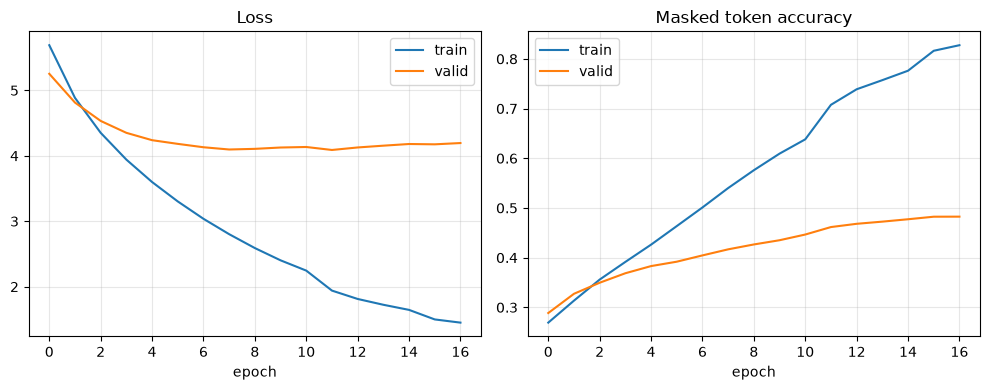

In [12]:
# [학습 곡선] train/validation loss와 PAD를 제외한 token accuracy를 시각화합니다.
# 두 곡선의 차이를 통해 과적합 여부와 학습 진행 상태를 확인할 수 있습니다.

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['valid_loss'], label='valid')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['valid_acc'], label='valid')
plt.title('Masked token accuracy'); plt.xlabel('epoch'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Step 5. 모델 평가하기

학습 시에는 정답을 입력으로 받는 Teacher Forcing을 사용하지만, 추론 시에는 `<BOS>`부터 시작하여 모델이 직전에 생성한 토큰을 다음 입력으로 넣는 자기회귀 방식을 사용합니다. `<EOS>`가 나오거나 최대 길이에 도달하면 생성을 종료합니다.

In [13]:
# [개선된 추론] greedy decoding에 반복 n-gram 억제를 추가합니다.
@torch.no_grad()
def generate_response(sentence, max_length=MAX_LENGTH, no_repeat_ngram_size=2):
    model.eval()
    src_ids = [BOS_ID] + sp.encode(clean_text(sentence), out_type=int) + [EOS_ID]
    src_ids = src_ids[:MAX_LENGTH]
    src_ids += [PAD_ID] * (MAX_LENGTH - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    generated = [BOS_ID]
    for _ in range(max_length - 1):
        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model(src, tgt)[0, -1].clone()
        if no_repeat_ngram_size > 1 and len(generated) >= no_repeat_ngram_size - 1:
            prefix = tuple(generated[-(no_repeat_ngram_size - 1):])
            for i in range(len(generated) - no_repeat_ngram_size + 1):
                if tuple(generated[i:i + no_repeat_ngram_size - 1]) == prefix:
                    logits[generated[i + no_repeat_ngram_size - 1]] = -float('inf')
        logits[PAD_ID] = -float('inf')
        logits[BOS_ID] = -float('inf')
        next_id = int(logits.argmax())
        if next_id == EOS_ID:
            break
        generated.append(next_id)
    return sp.decode([i for i in generated[1:] if i not in (PAD_ID, BOS_ID, EOS_ID)]).strip()

def chat():
    print('대화를 시작합니다. 종료하려면 quit 또는 exit를 입력하세요.')
    while True:
        text = input('나: ').strip()
        if text.lower() in {'quit', 'exit', '종료'}:
            print('챗봇: 대화를 종료합니다.')
            break
        if text:
            print('챗봇:', generate_response(text))

# 학습 후 실행: chat()

In [14]:
# [대화형 평가] 대표 질문을 입력하여 학습된 챗봇의 응답을 정성적으로 확인합니다.
# 실제 실행 시에는 학습 품질, 문맥 적절성, 반복 응답 여부를 함께 평가합니다.

test_questions = ['안녕하세요', '오늘 기분이 어때?', '고마워', '요즘 힘들어']
for question in test_questions:
    print(f'질문: {question}')
    print(f'응답: {generate_response(question)}')
    print('-' * 40)

질문: 안녕하세요
응답: 안녕하세요.
----------------------------------------
질문: 오늘 기분이 어때?
응답: 맛나게 드세요.
----------------------------------------
질문: 고마워
응답: 감사합니다.
----------------------------------------
질문: 요즘 힘들어
응답: 당신이 행복하길 바라요.
----------------------------------------


## 챗봇 학습 성능 개선 보고서

기존 학습 로그에서는 **훈련 손실이 계속 감소하는 반면 검증 손실은 12 epoch 전후에서 최저점을 찍고 다시 상승**했습니다. 즉, 모델이 학습 데이터의 답변 패턴을 외우는 과적합이 발생했고, 마지막 epoch의 모델을 그대로 추론에 사용한 것이 응답 품질을 악화시킨 핵심 원인입니다. 기존 결과에서도 `valid loss`가 3.8848까지 내려간 뒤 4.0402로 상승했으며, 마지막 epoch의 응답은 질문과 무관한 문장을 출력했습니다.

수정본은 검증 손실이 가장 낮은 모델만 저장·복원하고, 학습률을 검증 손실에 따라 낮추며, 일정 기간 개선이 없으면 조기 종료하도록 변경했습니다. 또한 PAD를 제외한 **전체 토큰 기준의 정확한 손실·정확도 집계**, label smoothing, 입력 길이 확장, FFN 용량 보강, 반복 2-gram 억제를 적용했습니다.

### 기존 학습 결과의 문제점

기존 로그에서는 훈련 손실이 계속 감소했지만 검증 손실은 약 12 epoch 전후에서 최저점에 도달한 뒤 상승했습니다.

| 구간 | 관찰된 결과 |
|---|---|
| Epoch 1~12 | 훈련 손실과 검증 손실이 함께 감소 |
| Epoch 12 전후 | 검증 손실 최저점 형성: 약 `3.8848` |
| Epoch 13~20 | 훈련 손실은 계속 감소하지만 검증 손실은 상승 |
| 마지막 epoch | 학습 데이터에는 더 잘 맞지만 일반화 성능은 악화 |

### 주요 변경 사항

| 구분 | 기존 상태 | 최신 수정 상태 | 기대 효과 |
|---|---|---|---|
| 과적합 제어 | 정해진 epoch까지 무조건 학습 | `PATIENCE=5` Early Stopping | 검증 성능 악화 구간의 학습 방지 |
| 개선 판정 | 별도 기준 없음 | `valid_loss < best_valid_loss - MIN_DELTA` | 미세한 변동을 개선으로 오판하지 않음 |
| 최소 개선 폭 | 없음 | `MIN_DELTA=1e-3` | 의미 있는 검증 손실 감소만 인정 |
| Best 모델 | 마지막 모델 저장 | 검증 손실 최저 모델 저장·복원 | 가장 좋은 일반화 모델 사용 |
| 체크포인트 | epoch별 마지막 상태 중심 | 개선된 epoch의 상태 저장 | 학습 중단 후에도 best 모델 보존 |
| 학습률 | 고정 또는 학습 손실 기준 | 검증 손실 기준 `ReduceLROnPlateau` | 검증 정체 후 안정적 미세 조정 |
| 손실 함수 | PAD 무시 | PAD 무시 + `label_smoothing=0.05` | 패딩 오차 제거 및 과도한 확신 완화 |
| metric 집계 | 배치 평균을 다시 평균 | 실제 non-PAD 토큰 수 기준 집계 | 배치별 패딩 수 차이에 따른 왜곡 감소 |
| 모델 표현력 | `FF_DIM=256` | `FF_DIM=512` | 서브워드 조합 표현력 보강 |
| 입력 길이 | `MAX_LENGTH=40` | `MAX_LENGTH=48` | 긴 질문·답변의 잘림 감소 |
| 추론 | 반복 제한 없음 | 반복 2-gram 억제 | 동일 구절 반복 출력 감소 |

## 회고

이 프로젝트에서는 한국어 대화 쌍을 정제하고 SentencePiece로 서브워드 토큰화한 뒤, 패딩·look-ahead 마스크가 적용된 Encoder–Decoder Transformer를 학습했습니다. 학습 단계에서는 `decoder_input = answer[:-1]`, `label = answer[1:]` 형태로 Teacher Forcing을 구현했고, 추론 단계에서는 생성 토큰을 다시 디코더 입력에 넣는 자기회귀 생성을 구현했습니다.

최종 평가에서는 학습·검증 loss 곡선, PAD를 제외한 token accuracy, 예시 질문에 대한 응답의 문맥 적절성·문장 완결성·중복 여부를 함께 확인합니다. 작은 데이터셋과 작은 모델을 사용한 결과는 교육용 프로젝트의 기준선이며, 더 자연스러운 응답을 위해서는 데이터 규모, 모델 크기, 학습 epoch, decoding 전략을 개선할 수 있습니다.